# %% [markdown]
# Evaluación de métricas de generación para RAG usando el benchmark EKRAG

Este notebook aplica los tests de **Correctness**, **Relevance** y **Faithfulness** a un pipeline RAG basado en FAISS y un modelo LLM (Qwen), de acuerdo con el benchmark EKRAG.

---

# %% [markdown]
## 1. Configuración e imports

Importamos librerías necesarias para:

- Cargar índice FAISS y RAG Chain
- Manejar embeddings y similitudes
- Usar LLM como "juez" para evaluar respuestas
- Presentar resultados en un DataFrame

In [13]:
import os
import json
import pandas as pd
from tqdm import tqdm

# FAISS y Embeddings
from langchain.vectorstores import FAISS
from langchain.embeddings import SentenceTransformerEmbeddings

# LLM y RAG
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA

# Métricas
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [14]:
# Parameters (Papermill will overwrite)
faiss_index_path = r"E:\RAG_Project\data\processed\index\FAISS"
embedding_model  = "ProsusAI/finbert"
llm_model        = "Qwen/Qwen1.5-0.5B"
retriever_k      = 5
temperature      = 0.2
max_new_tokens   = 512
top_k            = 50
similarity_threshold = 0.8
test_csv_path    = r"E:\RAG_Project\notebooks\evaluation\test_questions.csv"
n_test_rows      = 2
experiment_name  = "default_eval_run"
run_id           = "default_run_id"

In [15]:
def cos_sim(a, b) -> float:
    """
    Convierte a y b en np.ndarray y devuelve la similitud de coseno.
    """
    # Convertir listas a arrays
    a_arr = np.array(a)
    b_arr = np.array(b)
    # sklearn devuelve una matriz 1×1, así que extraemos el valor escalar
    return float(cosine_similarity(a_arr.reshape(1, -1), b_arr.reshape(1, -1))[0][0])

In [16]:
# Funciones auxiliares
def get_embeds(texts: list[str], embed_model) -> list[list[float]]:
    return embed_model.embed_documents(texts)

def cos_sim(a: list[float], b: list[float]) -> float:
    return float(cosine_similarity(
        np.array(a).reshape(1, -1),
        np.array(b).reshape(1, -1)
    )[0][0])

def extract_answer(text):
    match = re.search(r"(?i)Answer:\s*(.*)", text.strip())
    return match.group(1).strip() if match else text.strip()

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain")
model = AutoModel.from_pretrained("yiyanghkust/finbert-pretrain")

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  # last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size())
    return torch.sum(token_embeddings * input_mask_expanded, 1) / \
           torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Example usage
inputs = tokenizer("Cash flow from operations increased.", return_tensors="pt", padding=True, truncation=True)
with torch.no_grad():
    outputs = model(**inputs)

sentence_embedding = mean_pooling(outputs, inputs["attention_mask"])



In [17]:
# Load FAISS index
embedder = SentenceTransformerEmbeddings(model_name=embedding_model)
db = FAISS.load_local(
    folder_path=faiss_index_path,
    embeddings=embedder,
    allow_dangerous_deserialization=True
)
retriever = db.as_retriever(search_kwargs={"k": retriever_k})

C:\Users\Fmlia Gutierrez\AppData\Local\Temp\ipykernel_12496\640005701.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedder = SentenceTransformerEmbeddings(model_name=embedding_model)
No sentence-transformers model found with name ProsusAI/finbert. Creating a new one with MEAN pooling.


In [10]:
# %%
# --- Configuración ---
#faiss_index_path = r"E:\RAG_Project\data\processed\index\FAISS"
embedder = SentenceTransformerEmbeddings(model_name=embedding_model)
# Cargar índice
print("🔄 Cargando índice FAISS...")
db = FAISS.load_local(
    folder_path=faiss_index_path,
    embeddings=embedding_model,
    allow_dangerous_deserialization=True
)
retriever = db.as_retriever(search_kwargs={"k": 5})
print("✅ Índice FAISS cargado.")

NameError: name 'SentenceTransformerEmbeddings' is not defined

In [4]:
# Cargar LLM Qwen
print("🔄 Cargando modelo Qwen...")
model_id = "Qwen/Qwen1.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
pipe = pipeline(
    "text-generation", model=model, tokenizer=tokenizer,
    max_new_tokens=100, do_sample=True, top_k=5, temperature=0.2
)
llm = HuggingFacePipeline(pipeline=pipe)
print("✅ Modelo Qwen listo.")

🔄 Cargando modelo Qwen...


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Device set to use cuda:0


✅ Modelo Qwen listo.


C:\Users\Fmlia Gutierrez\AppData\Local\Temp\ipykernel_19060\1363198901.py:10: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


In [5]:
# Crear cadena RAG
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever,
    return_source_documents=True
)

# %% [markdown]
## 3. Cargar conjunto de evaluación

Se asume un CSV con columnas:
- `query`: consulta del usuario
- `ground_truth_answer`: respuesta esperada
- `ground_truth_context`: texto de contexto relevante (concatenado)

In [6]:
df= pd.read_csv(r'E:\RAG_Project\notebooks\evaluation\test_questions.csv', nrows=5)
df=df.rename(columns={'question': 'query','answer':'ground_truth_answer','evidence':'ground_truth_context'})

# %% [markdown]
## 4. Definición de funciones de métrica

Para cada métrica:
- **Correctness**: similitud entre respuesta generada y respuesta verdad de tierra
- **Relevance**: similitud entre respuesta generada y contexto
- **Faithfulness**: similitud entre contexto y respuesta (grado de grounding)

Se usa `cosine_similarity` sobre embeddings.


In [7]:
# %%
# Función para obtener embedding de texto
def get_embeds(texts, embed_model):
    return embed_model.embed_documents(texts)


In [8]:
# Evaluación automática con embeddings
class JudgeEM:
    def __init__(self, embed_model):
        self.model = embed_model
    def correctness(self, gen, truth):
        e1 = self.model.embed_query(gen)
        e2 = self.model.embed_query(truth)
        return cos_sim(e1, e2)
    def relevance(self, gen, context):
        e1 = self.model.embed_query(gen)
        e2 = self.model.embed_query(context)
        return cos_sim(e1, e2)
    def faithfulness(self, gen, context):
        # idem relevance (grado de grounding)
        return self.relevance(gen, context)

judge = JudgeEM(embedding_model)


# %% [markdown]
## 5. Loop de evaluación
a. Ejecutar cada query en el pipeline RAG
b. Calcular métricas
a. Guardar resultados

In [11]:
import re

def extract_answer(text):
    match = re.search(r"(?i)Answer:\s*(.*)", text.strip())
    return match.group(1).strip() if match else text.strip()

results = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    q = row['query']
    gt_ans = row['ground_truth_answer']
    gt_ctx = row['ground_truth_context']

    # Obtener generación y contexto usado
    resp = qa_chain({"query": q}, return_only_outputs=True)
    gen_ans = extract_answer(resp['result'])
    
    retrieved = " ".join([doc.page_content for doc in resp['source_documents']])

    # Calcular métricas
    corr = judge.correctness(gen_ans, gt_ans)
    rel = judge.relevance(gen_ans, gt_ctx)
    faith = judge.faithfulness(gen_ans, retrieved)

    results.append({
        'query': q,
        'gen_answer': gen_ans,
        'ground_truth_answer': gt_ans,
        'correctness': corr,
        'relevance': rel,
        'faithfulness': faith
    })

# Consolidar en DataFrame
df_res = pd.DataFrame(results)
#df_res.to_csv(r'E:\RAG_Project\notebooks\evaluation\ekrag_results.csv', index=False)
df_res.head()




100%|██████████| 5/5 [00:27<00:00,  5.41s/it]


,query,gen_answer,ground_truth_answer,correctness,relevance,faithfulness
0,What is the FY2018 capital expenditure amount ...,"The answer to the question ""What is the FY2018...",$1577.00,0.178017,0.343004,0.534582
1,Assume that you are a public equities analyst....,The year end FY2018 net PPNE for 3M is $17.0 b...,$8.70,0.272383,0.286168,0.300249
2,Is 3M a capital-intensive business based on FY...,Based on the annual test in the fourth quarter...,"No, the company is managing its CAPEX and Fixe...",0.206943,0.306382,0.168663
3,What drove operating margin change as of FY202...,The operating margin change as of FY2022 for 3...,Operating Margin for 3M in FY2022 has decrease...,0.741602,0.436280,0.699667
4,"If we exclude the impact of M&A, which segment...","If we exclude the impact of M&A, the segment t...",The consumer segment shrunk by 0.9% organically.,0.253935,0.261215,0.606923


In [21]:
df_res['gen_answer'][3]

"Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.\n\nOperating income:\n·\nOperating income margins declined 1.8 percentage points year-on-year, in part due to incremental strategic investments, which reduced margins by 1.8 percentage points.\nPERFORMANCE BY GEOGRAPHIC AR EA\nWhile 3M manages its businesses globally and believes its business segment results are the most relevant measure of performance, the Company also utilizes geographic area data as a secondary performance measure. Export sales are generally reported within the geographic area where the final sales to 3M customers are made. A portion of the products or components sold by 3M’s operations to its customers are exported by these customers to different geographic areas. As customers move their operations from one geographic area to another, 3M’s results will follow. Thus, net sales in a particular geographic a

# %% [markdown]
## 6. Análisis de resultados

Podemos visualizar distribuciones de cada métrica para identificar comportamiento general.

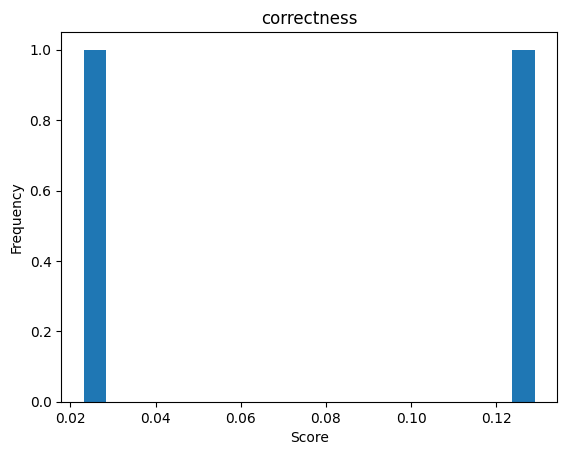

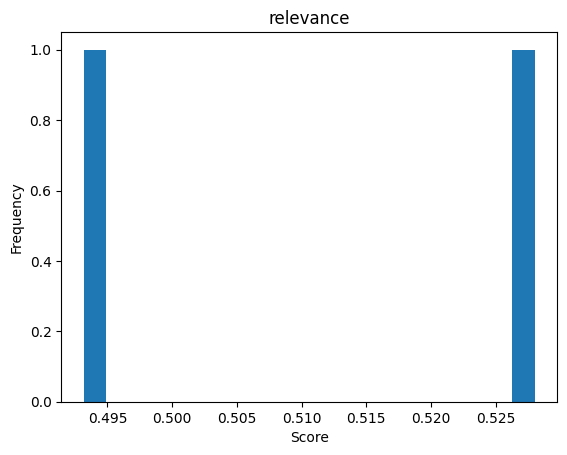

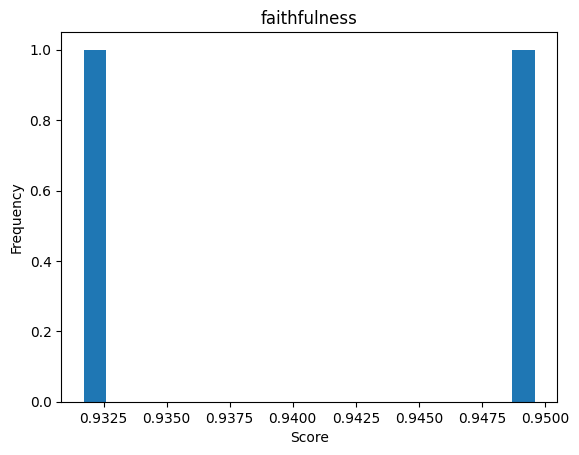

In [10]:
# %%
import matplotlib.pyplot as plt

for metric in ['correctness', 'relevance', 'faithfulness']:
    plt.figure()
    plt.hist(df_res[metric], bins=20)
    plt.title(metric)
    plt.xlabel('Score')
    plt.ylabel('Frequency')
    plt.show()
